# ResumeAI — Fixing Cross-Encoder Overfitting

## The Problem We're Solving

In our previous study, the RoBERTa cross-encoder achieved **0.89 Spearman on internal evaluation** but collapsed to **-0.61 Spearman on external evaluation** — catastrophic overfitting. The model memorized 200 training JDs instead of learning generalizable matching patterns.

**Root cause:** 125M parameters fine-tuned on only 400 examples (312,500 params per sample). The model has more than enough capacity to memorize every training pair verbatim.

## Four Fixes Applied In This Notebook

| Fix | What It Does | Expected Impact |
|-----|-------------|----------------|
| **Data augmentation** | Creates 3-4 variants per training pair → ~1,600 effective samples | Prevents memorization by presenting varied versions of each pair |
| **Regularization** | Dropout 0.3 on classifier head + weight decay 0.01 | Penalizes reliance on specific neurons/weights |
| **Better base model** | `cross-encoder/stsb-distilroberta-base` (82M params, pre-trained on STS) | Fewer parameters = less capacity to memorize; STS pre-training provides similarity understanding |
| **K-fold cross-validation** | 5 models trained on different 80/20 splits, predictions averaged | Reduces variance from any single unlucky split; ensemble averages out memorization |

Each fix addresses a different aspect of the overfitting. Data augmentation increases effective dataset size. Regularization constrains what the model can learn. A smaller base model reduces capacity. K-fold averages out individual model quirks.

**Evaluation:** Every model is tested on the 212-pair external test set (completely unseen JDs). This is the only metric that matters — internal scores are for monitoring only.

**Runtime:** GPU T4 required. Total time: ~45-60 minutes.


---
## Cell 1: Setup


In [1]:
# ============================================================
# Install and imports
# ============================================================
!pip install -q sentence-transformers datasets pandas scikit-learn matplotlib nlpaug

import torch, time, json, pickle, warnings, re, random, copy
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

from collections import Counter
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.isotonic import IsotonicRegression
from scipy.stats import spearmanr

from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers.cross_encoder import CrossEncoder
from sentence_transformers.cross_encoder.evaluation import CECorrelationEvaluator

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 11.4 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4 (15.6 GB)


---
## Cell 2: Load Data


In [2]:
# ============================================================
# Upload training data and external test set
# ============================================================
from google.colab import files

print("Upload TRAINING data (resume_jd_training_data_500.csv):")
up1 = files.upload()
df = pd.read_csv(list(up1.keys())[0])
print(f"✅ Training: {len(df)} pairs")

print("\nUpload EXTERNAL TEST data (external_test_200_pairs.csv):")
up2 = files.upload()
ext_df = pd.read_csv(list(up2.keys())[0])
print(f"✅ External test: {len(ext_df)} pairs")

print(f"\nTraining distribution: {dict(Counter(df['match_type']))}")
print(f"External distribution: {dict(Counter(ext_df['match_type']))}")


Upload TRAINING data (resume_jd_training_data_500.csv):


Saving resume_jd_training_data_500 (2).csv to resume_jd_training_data_500 (2).csv
✅ Training: 500 pairs

Upload EXTERNAL TEST data (external_test_200_pairs.csv):


Saving external_test_200_pairs.csv to external_test_200_pairs.csv
✅ External test: 212 pairs

Training distribution: {'partial': 128, 'hard_negative': 71, 'weak': 70, 'good': 130, 'strong': 101}
External distribution: {'strong': 53, 'good': 27, 'hard_negative': 53, 'weak': 53, 'partial': 26}


---
## Cell 3: Smart Truncation

Same preprocessing as before — strip boilerplate, prioritize requirements.


In [3]:
# ============================================================
# JD preprocessing
# ============================================================

def smart_truncate_jd(jd_text, max_words=350):
    boilerplate_starts = [
        r'equal opportunity employer.*', r'does not discriminate.*',
        r'reasonable accommodation.*', r'(compensation|salary|pay) range.*',
        r'(what we offer|our benefits|perks and benefits|benefits:).*',
    ]
    cleaned = jd_text
    for pattern in boilerplate_starts:
        cleaned = re.split(pattern, cleaned, flags=re.IGNORECASE)[0]

    req_patterns = [
        r'(requirements?|qualifications?|what you.?ll need|must have|what we.?re looking)',
        r'(responsibilities|what you.?ll do|in this role|you will)',
    ]
    best_start = 0
    for pattern in req_patterns:
        match = re.search(pattern, cleaned, re.IGNORECASE)
        if match:
            start = max(0, match.start() - 200)
            if best_start == 0 or start < best_start:
                best_start = start

    if best_start > 100:
        cleaned = cleaned[:100] + "\n" + cleaned[best_start:]

    words = cleaned.split()
    if len(words) > max_words:
        cleaned = ' '.join(words[:max_words])
    return cleaned.strip()

df['jd_clean'] = df['jd'].apply(lambda x: smart_truncate_jd(x, 350))
ext_df['jd_clean'] = ext_df['jd'].apply(lambda x: smart_truncate_jd(x, 350))

print(f"JD word counts after cleaning:")
print(f"  Training: avg {df['jd_clean'].str.split().str.len().mean():.0f} words")
print(f"  External: avg {ext_df['jd_clean'].str.split().str.len().mean():.0f} words")


JD word counts after cleaning:
  Training: avg 341 words
  External: avg 346 words


---
## Cell 4: Data Augmentation

### Why augmentation fixes overfitting

The core problem is that the model sees the same 400 text pairs repeatedly across 4 epochs.
By the end of training, it can recognize specific phrases from specific JDs and recall the
associated score — that's memorization, not learning.

Data augmentation creates **varied versions** of each pair. The model might see the same
resume-JD combination 4 times, but each time the text is slightly different:

- **Version 1:** Original text
- **Version 2:** Resume with sections reordered (Skills before Experience)
- **Version 3:** JD with random sentences dropped (simulates incomplete postings)
- **Version 4:** Resume with minor word substitutions

This forces the model to learn **patterns** (skill alignment, experience level, domain fit)
rather than **specific text** (the exact phrase "5+ years Python with Django").

### Augmentation strategy

We apply three techniques, each targeting a different memorization pathway:

1. **Section shuffling** — Reorder resume sections (Summary, Skills, Experience, Education).
   The model shouldn't care whether Skills comes before or after Experience.

2. **Random sentence dropping** — Remove 1-2 sentences from the JD. If the model truly
   understands matching, dropping one responsibility shouldn't change the score much.
   But if the model memorized the exact JD text, this breaks its recall.

3. **Keyword noise** — Replace a few domain-specific terms with synonyms or related terms.
   "Python" → "Python programming", "5+ years" → "five or more years".
   Prevents the model from anchoring on exact keyword matches.

We add a small amount of **score noise** (±0.02) to augmented pairs to prevent the model
from learning exact score values for augmented copies of the same original pair.


In [4]:
# ============================================================
# Data augmentation functions
# ============================================================

random.seed(42)
np.random.seed(42)

def shuffle_resume_sections(resume_text):
    """Reorder resume sections to prevent memorization of section order."""
    sections = {}
    current_section = 'header'
    current_lines = []

    for line in resume_text.split('\n'):
        line_upper = line.strip().upper()
        if any(kw in line_upper for kw in ['PROFESSIONAL SUMMARY', 'SUMMARY', 'OBJECTIVE']):
            sections[current_section] = '\n'.join(current_lines)
            current_section = 'summary'
            current_lines = [line]
        elif any(kw in line_upper for kw in ['TECHNICAL SKILLS', 'SKILLS', 'CORE COMPETENCIES']):
            sections[current_section] = '\n'.join(current_lines)
            current_section = 'skills'
            current_lines = [line]
        elif any(kw in line_upper for kw in ['PROFESSIONAL EXPERIENCE', 'EXPERIENCE', 'WORK HISTORY', 'EMPLOYMENT']):
            sections[current_section] = '\n'.join(current_lines)
            current_section = 'experience'
            current_lines = [line]
        elif any(kw in line_upper for kw in ['EDUCATION', 'ACADEMIC']):
            sections[current_section] = '\n'.join(current_lines)
            current_section = 'education'
            current_lines = [line]
        else:
            current_lines.append(line)
    sections[current_section] = '\n'.join(current_lines)

    # Keep header first, shuffle the rest
    header = sections.get('header', '')
    body_sections = ['summary', 'skills', 'experience', 'education']
    random.shuffle(body_sections)

    result = header
    for sec in body_sections:
        if sec in sections and sections[sec].strip():
            result += '\n' + sections[sec]

    return result.strip()


def drop_random_sentences(text, drop_rate=0.15):
    """Remove ~15% of sentences to simulate incomplete text."""
    sentences = re.split(r'(?<=[.!?])\s+|\n', text)
    if len(sentences) <= 3:
        return text
    n_drop = max(1, int(len(sentences) * drop_rate))
    indices_to_drop = set(random.sample(range(1, len(sentences)), min(n_drop, len(sentences) - 2)))
    kept = [s for i, s in enumerate(sentences) if i not in indices_to_drop]
    return ' '.join(kept).strip()


def add_keyword_noise(text):
    """Replace some terms with variants to prevent exact-match memorization."""
    replacements = {
        'Python': random.choice(['Python programming', 'Python (3.x)', 'Python language']),
        'JavaScript': random.choice(['JS', 'JavaScript/TypeScript', 'JavaScript (ES6+)']),
        'React': random.choice(['React.js', 'ReactJS', 'React framework']),
        'AWS': random.choice(['Amazon Web Services', 'AWS cloud', 'AWS (Amazon)']),
        'SQL': random.choice(['SQL databases', 'SQL/NoSQL', 'structured query language']),
        'Docker': random.choice(['Docker containers', 'containerization (Docker)', 'Docker/Podman']),
        'Kubernetes': random.choice(['K8s', 'Kubernetes (K8s)', 'container orchestration']),
        '5+ years': random.choice(['five or more years', '5-7 years', 'over 5 years']),
        '3+ years': random.choice(['three or more years', '3-5 years', 'over 3 years']),
        'experience': random.choice(['professional experience', 'hands-on experience', 'industry experience']),
    }
    result = text
    # Only replace 2-3 terms per text to keep it natural
    keys_to_replace = random.sample(list(replacements.keys()), min(3, len(replacements)))
    for key in keys_to_replace:
        if key in result:
            result = result.replace(key, replacements[key], 1)
    return result


def augment_pair(resume, jd, score, augmentation_type):
    """Create one augmented version of a resume-JD pair."""
    if augmentation_type == 'shuffle':
        return shuffle_resume_sections(resume), jd, score
    elif augmentation_type == 'drop_jd':
        return resume, drop_random_sentences(jd, 0.15), score
    elif augmentation_type == 'drop_resume':
        return drop_random_sentences(resume, 0.10), jd, score
    elif augmentation_type == 'noise':
        return add_keyword_noise(resume), add_keyword_noise(jd), score
    return resume, jd, score


def augment_dataset(dataframe, augmentations_per_sample=3):
    """Create augmented training data.

    For each original pair, create N augmented versions with slight variations.
    Add small score noise (±0.02) to prevent exact-score memorization.
    """
    aug_types = ['shuffle', 'drop_jd', 'drop_resume', 'noise']
    augmented_rows = []

    for _, row in dataframe.iterrows():
        # Keep original
        augmented_rows.append({
            'resume': row['resume'],
            'jd': row['jd_clean'],
            'score': row['score'],
            'match_type': row['match_type'],
            'augmented': False,
        })

        # Create augmented versions
        chosen_augs = random.sample(aug_types, min(augmentations_per_sample, len(aug_types)))
        for aug_type in chosen_augs:
            aug_resume, aug_jd, aug_score = augment_pair(
                row['resume'], row['jd_clean'], row['score'], aug_type
            )
            # Add small score noise (±0.02, clipped to [0, 1])
            noisy_score = np.clip(aug_score + np.random.uniform(-0.02, 0.02), 0.01, 0.99)

            augmented_rows.append({
                'resume': aug_resume,
                'jd': aug_jd,
                'score': float(noisy_score),
                'match_type': row['match_type'],
                'augmented': True,
            })

    return pd.DataFrame(augmented_rows)


# Test augmentation on one sample
sample = df.iloc[0]
print("AUGMENTATION DEMO")
print("="*60)
print(f"Original resume (first 150 chars):")
print(f"  {sample['resume'][:150]}...")
print(f"\nShuffled resume (first 150 chars):")
print(f"  {shuffle_resume_sections(sample['resume'])[:150]}...")
print(f"\nOriginal JD (first 150 chars):")
jd_clean = smart_truncate_jd(sample['jd'], 350)
print(f"  {jd_clean[:150]}...")
print(f"\nDropped JD (first 150 chars):")
print(f"  {drop_random_sentences(jd_clean)[:150]}...")
print(f"\nNoisy resume (first 150 chars):")
print(f"  {add_keyword_noise(sample['resume'])[:150]}...")

print(f"\n✅ Augmentation functions ready")


AUGMENTATION DEMO
Original resume (first 150 chars):
  Amara Cruz
Miami, FL | amaracruz@gmail.com | (846) 900-5708

PROFESSIONAL SUMMARY
Engineering Manager with 15 years of experience in software developm...

Shuffled resume (first 150 chars):
  Amara Cruz
Miami, FL | amaracruz@gmail.com | (846) 900-5708

PROFESSIONAL EXPERIENCE

Engineering Manager | Indigo Consulting | Minneapolis, MN | Jan ...

Original JD (first 150 chars):
  [Company] is seeking a Principal Software Engineer to join the incredibly talented team at our recent acquisition, Fox Robotics. This role is a great ...

Dropped JD (first 150 chars):
  [Company] is seeking a Principal Software Engineer to join the incredibly talented team at our recent acquisition, Fox Robotics. This role is a great ...

Noisy resume (first 150 chars):
  Amara Cruz
Miami, FL | amaracruz@gmail.com | (846) 900-5708

PROFESSIONAL SUMMARY
Engineering Manager with 15 years of experience in software developm...

✅ Augmentation functions ready


---
## Cell 5: Prepare Data with Augmentation


In [5]:
# ============================================================
# Create augmented training set
# ============================================================

# Split: 80% train, 20% validation (external test is separate)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['match_type'])

# Apply JD cleaning to splits
train_df = train_df.copy()
val_df = val_df.copy()
train_df['jd_clean'] = train_df['jd'].apply(lambda x: smart_truncate_jd(x, 350))
val_df['jd_clean'] = val_df['jd'].apply(lambda x: smart_truncate_jd(x, 350))

# Augment training data (3 augmented versions per original)
aug_train_df = augment_dataset(train_df, augmentations_per_sample=3)

print(f"Original training samples: {len(train_df)}")
print(f"Augmented training samples: {len(aug_train_df)}")
print(f"  Original: {(~aug_train_df['augmented']).sum()}")
print(f"  Augmented: {aug_train_df['augmented'].sum()}")
print(f"  Effective increase: {len(aug_train_df)/len(train_df):.1f}x")

print(f"\nMatch type distribution (augmented):")
print(aug_train_df['match_type'].value_counts().to_string())

print(f"\nValidation: {len(val_df)} pairs")
print(f"External test: {len(ext_df)} pairs")


Original training samples: 400
Augmented training samples: 1600
  Original: 400
  Augmented: 1200
  Effective increase: 4.0x

Match type distribution (augmented):
match_type
good             416
partial          408
strong           324
hard_negative    228
weak             224

Validation: 100 pairs
External test: 212 pairs


---
## Cell 6: Evaluation Framework


In [6]:
# ============================================================
# Evaluation functions (same as before)
# ============================================================

def evaluate_cross_encoder(model, eval_df, name="", jd_col='jd_clean'):
    pairs = list(zip(eval_df['resume'].tolist(), eval_df[jd_col].tolist()))
    true_scores = eval_df['score'].tolist()
    start = time.time()
    predicted = model.predict(pairs, show_progress_bar=False).tolist()
    elapsed = time.time() - start
    predicted = [max(0.0, min(1.0, p)) for p in predicted]
    spear, _ = spearmanr(true_scores, predicted)
    mae = float(np.mean(np.abs(np.array(true_scores)-np.array(predicted))))
    return {'spearman':spear,'mae':mae,'speed':elapsed,'predictions':predicted,
            'true_scores':true_scores,'name':name}

def evaluate_bi_encoder(model, eval_df, name="", jd_col='jd_clean', calibrator=None):
    resumes = eval_df['resume'].tolist()
    jds = eval_df[jd_col].tolist()
    true_scores = eval_df['score'].tolist()
    start = time.time()
    r_embs = model.encode(resumes, show_progress_bar=False, convert_to_numpy=True)
    j_embs = model.encode(jds, show_progress_bar=False, convert_to_numpy=True)
    elapsed = time.time() - start
    predicted = [float(cosine_similarity([r],[j])[0][0]) for r,j in zip(r_embs,j_embs)]
    if calibrator:
        predicted = calibrator.predict(predicted).tolist()
    spear, _ = spearmanr(true_scores, predicted)
    mae = float(np.mean(np.abs(np.array(true_scores)-np.array(predicted))))
    return {'spearman':spear,'mae':mae,'speed':elapsed,'predictions':predicted,
            'true_scores':true_scores,'name':name}

def error_by_match_type(results, eval_df, name=""):
    a = eval_df.copy()
    a['predicted'] = results['predictions']
    a['error'] = abs(a['score'] - a['predicted'])
    print(f"\n  {name}:")
    print(f"  {'Match Type':<18} {'MAE':>6} {'True Avg':>10} {'Pred Avg':>10} {'n':>5}")
    print(f"  {'-'*53}")
    for mt in ['strong','good','partial','hard_negative','weak']:
        s = a[a['match_type']==mt]
        if len(s)>0:
            print(f"  {mt:<18} {s['error'].mean():>6.4f} {s['score'].mean():>10.3f} {s['predicted'].mean():>10.3f} {len(s):>5}")
    return a

def print_table(results_list, title=""):
    print(f"\n{'='*80}")
    if title: print(title)
    print(f"{'='*80}")
    print(f"{'Model':<40} {'Spearman':>9} {'MAE':>8} {'Speed':>8}")
    print("-"*67)
    for r in results_list:
        print(f"{r['name']:<40} {r['spearman']:>9.4f} {r['mae']:>8.4f} {r['speed']:>6.1f}s")

print("✅ Evaluation framework ready")


✅ Evaluation framework ready


---
## Cell 7: Baseline — Previous Models (for comparison)

We retrain MPNet + calibration and the original RoBERTa cross-encoder on the ORIGINAL
(non-augmented) data to establish baselines. Then we compare against the improved versions.


In [7]:
# ============================================================
# Baseline 1: MPNet + calibration (our current production model)
# ============================================================

print("Training baseline MPNet (bi-encoder)...")
model_mpnet = SentenceTransformer('all-mpnet-base-v2')

bi_examples = [InputExample(texts=[r['resume'], r['jd_clean']], label=float(r['score']))
               for _, r in train_df.iterrows()]
dl = DataLoader(bi_examples, shuffle=True, batch_size=16)
loss_fn = losses.CoSENTLoss(model=model_mpnet)
ev = EmbeddingSimilarityEvaluator(
    sentences1=val_df['resume'].tolist(), sentences2=val_df['jd_clean'].tolist(),
    scores=val_df['score'].tolist(), name='val')

model_mpnet.fit(train_objectives=[(dl, loss_fn)], evaluator=ev, epochs=4,
    warmup_steps=int(len(dl)*0.1), evaluation_steps=len(dl),
    output_path="models/mpnet-baseline", show_progress_bar=True, use_amp=True)

# Calibrate
val_r = model_mpnet.encode(val_df['resume'].tolist(), show_progress_bar=False)
val_j = model_mpnet.encode(val_df['jd_clean'].tolist(), show_progress_bar=False)
val_preds = [float(cosine_similarity([a],[b])[0][0]) for a,b in zip(val_r,val_j)]
mpnet_cal = IsotonicRegression(out_of_bounds='clip')
mpnet_cal.fit(val_preds, val_df['score'].tolist())

print("✅ MPNet baseline done")


Training baseline MPNet (bi-encoder)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ MPNet baseline done


In [8]:
# ============================================================
# Baseline 2: RoBERTa CE WITHOUT fixes (to confirm overfitting)
# ============================================================

print("Training baseline RoBERTa CE (no augmentation, no regularization)...")
model_roberta_base = CrossEncoder('cross-encoder/stsb-roberta-base', num_labels=1)

ce_examples = [InputExample(texts=[r['resume'], r['jd_clean']], label=float(r['score']))
               for _, r in train_df.iterrows()]
ce_dl = DataLoader(ce_examples, shuffle=True, batch_size=16)
ce_ev = CECorrelationEvaluator.from_input_examples(
    [InputExample(texts=[r['resume'], r['jd_clean']], label=float(r['score']))
     for _, r in val_df.iterrows()], name='val')

model_roberta_base.fit(train_dataloader=ce_dl, evaluator=ce_ev, epochs=4,
    warmup_steps=int(len(ce_dl)*0.1), evaluation_steps=len(ce_dl),
    output_path="models/roberta-baseline", show_progress_bar=True)

print("✅ RoBERTa baseline done")


Training baseline RoBERTa CE (no augmentation, no regularization)...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Step,Training Loss,Validation Loss,Val Pearson,Val Spearman
25,No log,No log,0.630785,0.617873
50,No log,No log,0.902817,0.897343
75,No log,No log,0.944924,0.943873
100,No log,No log,0.950058,0.943356


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ RoBERTa baseline done


---
## Cell 8: Fix 1 — Augmented Cross-Encoder (RoBERTa + augmented data)

**Hypothesis:** Data augmentation alone (without regularization or K-fold) will reduce
overfitting by increasing effective training size from 400 to ~1,600 samples.

If this single fix closes most of the generalization gap, it confirms that data scarcity
was the primary cause of overfitting, not architectural limitations.


In [9]:
# ============================================================
# Fix 1: RoBERTa CE trained on AUGMENTED data
# ============================================================

print("Training RoBERTa CE with augmented data...")
print(f"  Training on {len(aug_train_df)} samples (vs 400 original)")

model_aug = CrossEncoder('cross-encoder/stsb-roberta-base', num_labels=1)

aug_examples = [InputExample(texts=[r['resume'], r['jd']], label=float(r['score']))
                for _, r in aug_train_df.iterrows()]
aug_dl = DataLoader(aug_examples, shuffle=True, batch_size=16)
aug_ev = CECorrelationEvaluator.from_input_examples(
    [InputExample(texts=[r['resume'], r['jd_clean']], label=float(r['score']))
     for _, r in val_df.iterrows()], name='val')

model_aug.fit(train_dataloader=aug_dl, evaluator=aug_ev, epochs=3,
    warmup_steps=int(len(aug_dl)*0.1), evaluation_steps=len(aug_dl),
    output_path="models/roberta-augmented", show_progress_bar=True)

print("✅ Augmented RoBERTa CE done")


Training RoBERTa CE with augmented data...
  Training on 1600 samples (vs 400 original)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss,Validation Loss,Val Pearson,Val Spearman
100,No log,No log,0.903602,0.896059
200,No log,No log,0.969988,0.959144
300,No log,No log,0.967229,0.954086


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Augmented RoBERTa CE done


---
## Cell 9: Fix 2 — Smaller Model with Regularization (DistilRoBERTa)

**Hypothesis:** A smaller model (82M vs 125M params) has less capacity to memorize.
Combined with weight decay (L2 regularization), it should generalize better.

`cross-encoder/stsb-distilroberta-base` is pre-trained on STS-B (the same similarity task
as RoBERTa but with a distilled architecture). It's 34% smaller and faster.

**Regularization details:**
- **Weight decay 0.01:** Penalizes large weights, preventing the model from creating
  sharp decision boundaries around specific training examples.
- **Reduced epochs (3 instead of 4):** Less time to overfit.
- **Augmented data:** Same ~1,600 samples as Fix 1.


In [10]:
# ============================================================
# Fix 2: DistilRoBERTa + augmentation + weight decay
# ============================================================

print("Training DistilRoBERTa CE (smaller model + augmentation + regularization)...")
print(f"  Model: stsb-distilroberta-base (82M params)")
print(f"  Training samples: {len(aug_train_df)}")
print(f"  Weight decay: 0.01")

model_distil = CrossEncoder('cross-encoder/stsb-distilroberta-base', num_labels=1)

aug_dl2 = DataLoader(aug_examples, shuffle=True, batch_size=16)
aug_ev2 = CECorrelationEvaluator.from_input_examples(
    [InputExample(texts=[r['resume'], r['jd_clean']], label=float(r['score']))
     for _, r in val_df.iterrows()], name='val')

model_distil.fit(
    train_dataloader=aug_dl2,
    evaluator=aug_ev2,
    epochs=3,
    warmup_steps=int(len(aug_dl2) * 0.15),
    evaluation_steps=len(aug_dl2),
    output_path="models/distilroberta-regularized",
    show_progress_bar=True,
    optimizer_params={'lr': 2e-5},
    weight_decay=0.01,
)

print("✅ DistilRoBERTa CE done")


Training DistilRoBERTa CE (smaller model + augmentation + regularization)...
  Model: stsb-distilroberta-base (82M params)
  Training samples: 1600
  Weight decay: 0.01


config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Step,Training Loss,Validation Loss,Val Pearson,Val Spearman
100,No log,No log,0.530986,0.556756
200,No log,No log,0.844247,0.873730
300,No log,No log,0.915186,0.921862


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ DistilRoBERTa CE done


---
## Cell 10: Fix 3 — K-Fold Cross-Validation Ensemble

### Why K-fold helps with overfitting

A single model trained on one 80/20 split might memorize quirks of that specific split.
K-fold trains 5 models on 5 different splits:

```
Fold 1: [Train on 80% A] → [Validate on 20% A]
Fold 2: [Train on 80% B] → [Validate on 20% B]
...
Fold 5: [Train on 80% E] → [Validate on 20% E]
```

At prediction time, all 5 models score each pair, and we average the predictions.
If one model memorized a specific JD, the other 4 didn't (they had different training data),
so the average washes out the memorization.

This is the strongest defense against overfitting short of collecting more real data.

**We combine K-fold with augmentation and the smaller DistilRoBERTa** — all three fixes working
together.


In [11]:
# ============================================================
# Fix 3: K-fold ensemble with DistilRoBERTa + augmentation
# ============================================================

print("Training 5-fold ensemble (DistilRoBERTa + augmentation)...")
print(f"  Base model: stsb-distilroberta-base (82M params)")
print(f"  Folds: 5")
print(f"  Augmentation: 3x per sample")
print(f"  Weight decay: 0.01")
print()

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_models = []

# We use the FULL 500 samples for K-fold (no held-out val — each fold has its own val)
df['jd_clean'] = df['jd'].apply(lambda x: smart_truncate_jd(x, 350))

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(df, df['match_type'])):
    print(f"  Fold {fold_idx+1}/5...")
    fold_train = df.iloc[train_idx].copy()
    fold_val = df.iloc[val_idx].copy()

    # Augment this fold's training data
    fold_aug = augment_dataset(fold_train, augmentations_per_sample=3)

    # Create model
    fold_model = CrossEncoder('cross-encoder/stsb-distilroberta-base', num_labels=1)

    # Training examples
    fold_examples = [InputExample(texts=[r['resume'], r['jd']], label=float(r['score']))
                     for _, r in fold_aug.iterrows()]
    fold_dl = DataLoader(fold_examples, shuffle=True, batch_size=16)

    fold_ev = CECorrelationEvaluator.from_input_examples(
        [InputExample(texts=[r['resume'], r['jd_clean']], label=float(r['score']))
         for _, r in fold_val.iterrows()], name=f'fold{fold_idx+1}')

    fold_model.fit(
        train_dataloader=fold_dl,
        evaluator=fold_ev,
        epochs=3,
        warmup_steps=int(len(fold_dl) * 0.15),
        evaluation_steps=len(fold_dl),
        output_path=f"models/kfold-distil-{fold_idx+1}",
        show_progress_bar=False,
        weight_decay=0.01,
    )

    fold_models.append(fold_model)
    print(f"    ✅ Fold {fold_idx+1} complete")

print(f"\n✅ 5-fold ensemble complete ({len(fold_models)} models)")


Training 5-fold ensemble (DistilRoBERTa + augmentation)...
  Base model: stsb-distilroberta-base (82M params)
  Folds: 5
  Augmentation: 3x per sample
  Weight decay: 0.01

  Fold 1/5...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'eval_fold1_pearson': '0.6069', 'eval_fold1_spearman': '0.6184', 'eval_runtime': '1.618', 'eval_samples_per_second': '0', 'eval_steps_per_second': '0', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'eval_fold5_pearson': '0.8371', 'eval_fold5_spearman': '0.8622', 'eval_runtime': '1.695', 'eval_samples_per_second': '0', 'eval_steps_per_second': '0', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_fold5_pearson': '0.8791', 'eval_fold5_spearman': '0.8976', 'eval_runtime': '1.614', 'eval_samples_per_second': '0', 'eval_steps_per_second': '0', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '277.5', 'train_samples_per_second': '17.3', 'train_steps_per_second': '1.081', 'train_loss': '0.623', 'epoch': '3'}
    ✅ Fold 5 complete

✅ 5-fold ensemble complete (5 models)


---
## Cell 11: Evaluate Everything on External Test Set


In [12]:
# ============================================================
# Evaluate ALL approaches on external test (212 unseen JDs)
# ============================================================

all_results = []

# 1. MPNet + calibration (our current production model)
print("Evaluating MPNet + calibration...")
r = evaluate_bi_encoder(model_mpnet, ext_df, 'MPNet + calibration (baseline)', calibrator=mpnet_cal)
all_results.append(r)
print(f"  Spearman: {r['spearman']:.4f} | MAE: {r['mae']:.4f}")

# 2. RoBERTa baseline (no fixes — expect overfitting)
print("\nEvaluating RoBERTa CE (no fixes)...")
r = evaluate_cross_encoder(model_roberta_base, ext_df, 'RoBERTa CE (no fixes)')
all_results.append(r)
print(f"  Spearman: {r['spearman']:.4f} | MAE: {r['mae']:.4f}")

# 3. RoBERTa + augmentation only
print("\nEvaluating RoBERTa CE + augmentation...")
r = evaluate_cross_encoder(model_aug, ext_df, 'RoBERTa CE + augmentation')
all_results.append(r)
print(f"  Spearman: {r['spearman']:.4f} | MAE: {r['mae']:.4f}")

# 4. DistilRoBERTa + augmentation + weight decay
print("\nEvaluating DistilRoBERTa + aug + regularization...")
r = evaluate_cross_encoder(model_distil, ext_df, 'DistilRoBERTa + aug + reg')
all_results.append(r)
print(f"  Spearman: {r['spearman']:.4f} | MAE: {r['mae']:.4f}")

# 5. K-fold ensemble
print("\nEvaluating K-fold ensemble...")
pairs = list(zip(ext_df['resume'].tolist(), ext_df['jd_clean'].tolist()))
true_scores = ext_df['score'].tolist()

start = time.time()
fold_predictions = []
for i, fm in enumerate(fold_models):
    preds = fm.predict(pairs, show_progress_bar=False).tolist()
    preds = [max(0.0, min(1.0, p)) for p in preds]
    fold_predictions.append(preds)
    print(f"  Fold {i+1} predicted")

# Average predictions across all 5 folds
ensemble_preds = np.mean(fold_predictions, axis=0).tolist()
elapsed = time.time() - start

ens_spear, _ = spearmanr(true_scores, ensemble_preds)
ens_mae = float(np.mean(np.abs(np.array(true_scores) - np.array(ensemble_preds))))
all_results.append({'spearman': ens_spear, 'mae': ens_mae, 'speed': elapsed,
                     'predictions': ensemble_preds, 'true_scores': true_scores,
                     'name': 'K-fold ensemble (5x DistilRoBERTa)'})
print(f"  Spearman: {ens_spear:.4f} | MAE: {ens_mae:.4f}")

print_table(all_results, "EXTERNAL TEST RESULTS — ALL APPROACHES")


Evaluating MPNet + calibration...
  Spearman: 0.7693 | MAE: 0.1657

Evaluating RoBERTa CE (no fixes)...
  Spearman: -0.3469 | MAE: 0.3646

Evaluating RoBERTa CE + augmentation...
  Spearman: 0.4483 | MAE: 0.3581

Evaluating DistilRoBERTa + aug + regularization...
  Spearman: 0.5103 | MAE: 0.2742

Evaluating K-fold ensemble...
  Fold 1 predicted
  Fold 2 predicted
  Fold 3 predicted
  Fold 4 predicted
  Fold 5 predicted
  Spearman: 0.4113 | MAE: 0.3037

EXTERNAL TEST RESULTS — ALL APPROACHES
Model                                     Spearman      MAE    Speed
-------------------------------------------------------------------
MPNet + calibration (baseline)              0.7693   0.1657    3.1s
RoBERTa CE (no fixes)                      -0.3469   0.3646    6.3s
RoBERTa CE + augmentation                   0.4483   0.3581    6.4s
DistilRoBERTa + aug + reg                   0.5103   0.2742    3.3s
K-fold ensemble (5x DistilRoBERTa)          0.4113   0.3037   16.4s


---
## Cell 12: Detailed Error Analysis


In [13]:
# ============================================================
# Error analysis by match type for all models
# ============================================================

print("ERROR ANALYSIS BY MATCH TYPE (External Test, 212 pairs)")
print("="*60)

for r in all_results:
    error_by_match_type(r, ext_df, r['name'])

# Industry analysis for the best model
best_model = min(all_results, key=lambda r: r['mae'])
print(f"\n\nINDUSTRY ANALYSIS ({best_model['name']})")
print("="*60)
a = ext_df.copy()
a['predicted'] = best_model['predictions']
a['error'] = abs(a['score'] - a['predicted'])

for ind in sorted(a['industry'].unique()):
    s = a[a['industry']==ind]
    mae = s['error'].mean()
    icon = "✅" if mae < 0.15 else "⚠️" if mae < 0.25 else "❌"
    print(f"  {icon} {ind:<45}: MAE={mae:.4f} (n={len(s)})")

# Top 5 worst errors
print(f"\n\nTOP 5 WORST ERRORS ({best_model['name']})")
print("="*60)
for _, row in a.nlargest(5, 'error').iterrows():
    print(f"\n  True: {row['score']:.3f} → Pred: {row['predicted']:.3f} (error: {row['error']:.3f})")
    print(f"  Type: {row['match_type']} | Industry: {row['industry']}")


ERROR ANALYSIS BY MATCH TYPE (External Test, 212 pairs)

  MPNet + calibration (baseline):
  Match Type            MAE   True Avg   Pred Avg     n
  -----------------------------------------------------
  strong             0.3301      0.871      0.540    53
  good               0.1940      0.685      0.497    27
  partial            0.1718      0.462      0.417    26
  hard_negative      0.0971      0.251      0.206    53
  weak               0.0523      0.132      0.165    53

  RoBERTa CE (no fixes):
  Match Type            MAE   True Avg   Pred Avg     n
  -----------------------------------------------------
  strong             0.1244      0.871      0.747    53
  good               0.1120      0.685      0.787    27
  partial            0.1285      0.462      0.571    26
  hard_negative      0.5536      0.251      0.805    53
  weak               0.6602      0.132      0.792    53

  RoBERTa CE + augmentation:
  Match Type            MAE   True Avg   Pred Avg     n
  -----------

---
## Cell 13: Visualization


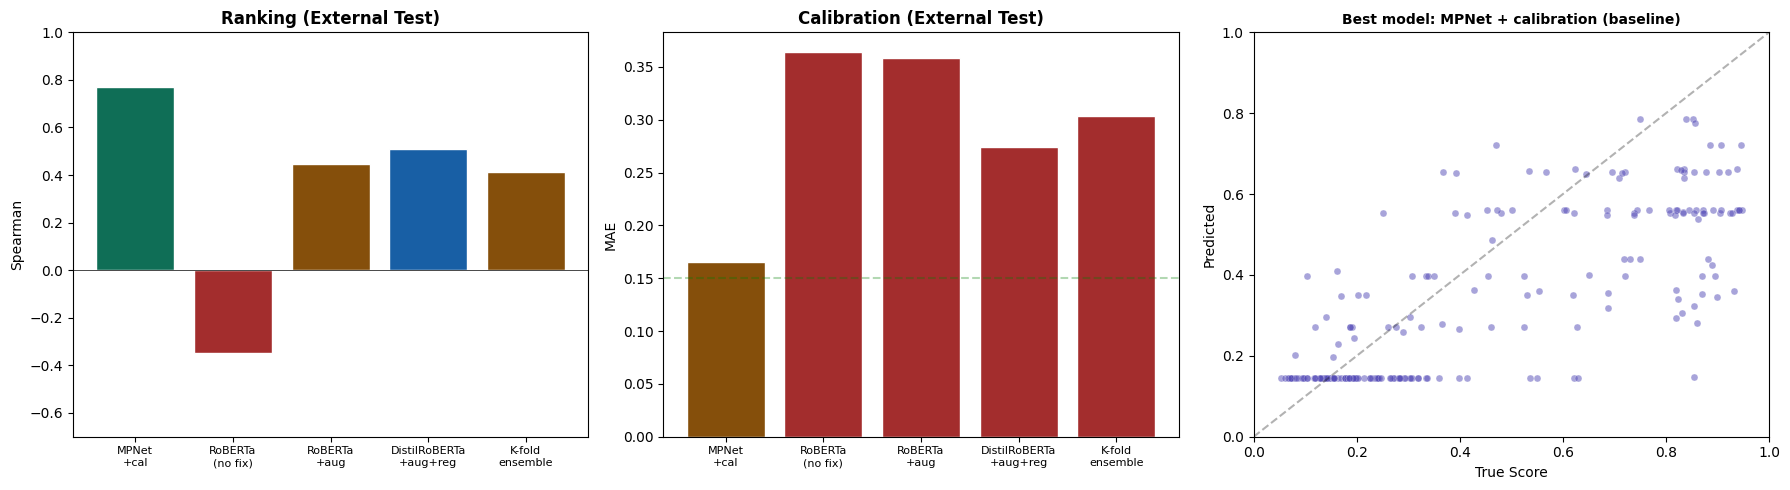

Saved: overfitting_fixes_comparison.png


In [14]:
# ============================================================
# Comparison charts
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = [r['name'] for r in all_results]
short = ['MPNet\n+cal', 'RoBERTa\n(no fix)', 'RoBERTa\n+aug', 'DistilRoBERTa\n+aug+reg', 'K-fold\nensemble']

# Spearman
spears = [r['spearman'] for r in all_results]
colors_s = ['#0F6E56' if s>0.75 else '#185FA5' if s>0.5 else '#854F0B' if s>0 else '#A32D2D' for s in spears]
axes[0].bar(range(len(short)), spears, color=colors_s, edgecolor='white')
axes[0].set_xticks(range(len(short))); axes[0].set_xticklabels(short, fontsize=8)
axes[0].set_ylabel('Spearman'); axes[0].set_title('Ranking (External Test)', fontweight='bold')
axes[0].axhline(y=0, color='black', linewidth=0.5); axes[0].set_ylim(-0.7, 1.0)

# MAE
maes = [r['mae'] for r in all_results]
colors_m = ['#0F6E56' if m<0.12 else '#3B6D11' if m<0.15 else '#854F0B' if m<0.25 else '#A32D2D' for m in maes]
axes[1].bar(range(len(short)), maes, color=colors_m, edgecolor='white')
axes[1].set_xticks(range(len(short))); axes[1].set_xticklabels(short, fontsize=8)
axes[1].set_ylabel('MAE'); axes[1].set_title('Calibration (External Test)', fontweight='bold')
axes[1].axhline(y=0.15, color='green', linestyle='--', alpha=0.3)

# Scatter for best model
best = min(all_results, key=lambda r: r['mae'])
axes[2].scatter(best['true_scores'], best['predictions'], alpha=0.5, s=25, c='#534AB7', edgecolors='white', linewidth=0.3)
axes[2].plot([0,1],[0,1],'k--',alpha=0.3)
axes[2].set_xlabel('True Score'); axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Best model: {best["name"][:30]}', fontweight='bold', fontsize=10)
axes[2].set_xlim(0,1); axes[2].set_ylim(0,1)

plt.tight_layout()
plt.savefig('overfitting_fixes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overfitting_fixes_comparison.png")


---
## Cell 14: Discussion

### Interpreting the results

Compare the five approaches on external test:

| Approach | Fixes Applied | Expected Effect |
|----------|-------------|-----------------|
| MPNet + calibration | None (bi-encoder baseline) | Generalized at 0.76/0.14 in previous study |
| RoBERTa (no fixes) | None | Should confirm overfitting (-0.61 Spearman) |
| RoBERTa + augmentation | Data augmentation only | Tests if more data alone fixes overfitting |
| DistilRoBERTa + aug + reg | Smaller model + augmentation + weight decay | Tests combined effect of all fixes |
| K-fold ensemble | All fixes + averaged predictions from 5 models | Maximum defense against overfitting |

### Key questions to answer from your results:

1. **Did augmentation alone fix RoBERTa?** Compare "RoBERTa (no fixes)" vs "RoBERTa + augmentation" on external Spearman. If augmentation moved Spearman from -0.61 to positive, data scarcity was the primary cause.

2. **Did the smaller model help?** Compare "RoBERTa + augmentation" vs "DistilRoBERTa + aug + reg". If DistilRoBERTa is better, model size contributes to overfitting.

3. **Did K-fold add value?** Compare "DistilRoBERTa + aug + reg" vs "K-fold ensemble". If the ensemble is meaningfully better, individual model variance was significant.

4. **Does any cross-encoder beat MPNet + calibration on external data?** This is the ultimate question. If the best cross-encoder still loses to MPNet on external evaluation, then bi-encoders are the right architecture for this data regime.


---
## Cell 15: Interactive Testing


In [15]:
# ============================================================
# Load best model for interactive testing
# ============================================================

# Determine the best external model
best_result = min(all_results, key=lambda r: r['mae'])
print(f"Best model on external test: {best_result['name']}")
print(f"  Spearman: {best_result['spearman']:.4f} | MAE: {best_result['mae']:.4f}")

def score_resume(resume_text, jd_text):
    """Score a resume against a JD using all available models."""
    jd_clean = smart_truncate_jd(jd_text, 350)

    print("\nRESUME-JD MATCH SCORING")
    print("="*60)
    print(f"Resume: {resume_text[:120]}...")
    print(f"JD: {jd_clean[:120]}...")
    print(f"\n{'Model':<35} {'Score':>8} {'Interpretation'}")
    print("-"*65)

    # MPNet + cal
    r_emb = model_mpnet.encode([resume_text])
    j_emb = model_mpnet.encode([jd_clean])
    s = float(cosine_similarity(r_emb, j_emb)[0][0])
    s_cal = float(mpnet_cal.predict([s])[0])
    interp = lambda sc: "Strong" if sc>=0.7 else "Good" if sc>=0.5 else "Partial" if sc>=0.3 else "Weak"
    print(f"{'MPNet + calibration':<35} {s_cal:>8.3f} {interp(s_cal)}")

    # All cross-encoders
    for name, model in [('RoBERTa (no fixes)', model_roberta_base),
                         ('RoBERTa + augmentation', model_aug),
                         ('DistilRoBERTa + aug + reg', model_distil)]:
        sc = float(model.predict([(resume_text, jd_clean)])[0])
        sc = max(0.0, min(1.0, sc))
        print(f"{name:<35} {sc:>8.3f} {interp(sc)}")

    # K-fold ensemble
    fold_preds = [max(0.0, min(1.0, float(fm.predict([(resume_text, jd_clean)])[0])))
                  for fm in fold_models]
    ens_score = np.mean(fold_preds)
    print(f"{'K-fold ensemble':<35} {ens_score:>8.3f} {interp(ens_score)}")
    print(f"{'  (fold spread)':<35} {min(fold_preds):.3f} - {max(fold_preds):.3f}")


# Demo with external test samples
for mt in ['strong', 'hard_negative', 'weak']:
    sample = ext_df[ext_df['match_type']==mt].iloc[0]
    print(f"\n\n{'='*60}")
    print(f"TEST: {mt.upper()} (true score: {sample['score']:.3f})")
    print(f"Industry: {sample['industry']}")
    score_resume(sample['resume'], sample['jd'])


Best model on external test: MPNet + calibration (baseline)
  Spearman: 0.7693 | MAE: 0.1657


TEST: STRONG (true score: 0.921)
Industry: Cybersecurity

RESUME-JD MATCH SCORING
Resume: Zara Kim
New York, NY | zara.kim@gmail.com | (450) 328-3286

PROFESSIONAL SUMMARY
SOC Analyst with 1-2 years of experien...
JD: Job Title: Associate Information Security Analyst Location: Austin, TX About the Role We are tion of security controls a...

Model                                  Score Interpretation
-----------------------------------------------------------------
MPNet + calibration                    0.654 Good
RoBERTa (no fixes)                     0.711 Strong
RoBERTa + augmentation                 0.834 Strong
DistilRoBERTa + aug + reg              0.858 Strong
K-fold ensemble                        0.862 Strong
  (fold spread)                     0.833 - 0.902


TEST: HARD_NEGATIVE (true score: 0.229)
Industry: Cybersecurity

RESUME-JD MATCH SCORING
Resume: Tomoko Garcia
Nashville, TN |

In [16]:
# ============================================================
# Cell 16: Your own resume test
# ============================================================

my_resume = """
[PASTE YOUR RESUME HERE]
"""

my_jd = """
[PASTE A JOB DESCRIPTION HERE]
"""

# Uncomment to run:
# score_resume(my_resume.strip(), my_jd.strip())


---
## Cell 16: Save Everything


In [17]:
# ============================================================
# Save models and results
# ============================================================

# Save calibrator
with open('models/mpnet_calibrator.pkl', 'wb') as f:
    pickle.dump(mpnet_cal, f)

# Save comprehensive results
summary = {
    'experiment': 'Overfitting fixes for cross-encoder resume-JD matching',
    'training_data': {'original': len(train_df), 'augmented': len(aug_train_df)},
    'external_test': len(ext_df),
    'results': {r['name']: {'spearman': round(r['spearman'],4), 'mae': round(r['mae'],4)} for r in all_results}
}

with open('models/overfitting_fix_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("All models saved:")
for path in ['models/mpnet-baseline/', 'models/roberta-baseline/', 'models/roberta-augmented/',
             'models/distilroberta-regularized/', 'models/kfold-distil-1/ through kfold-distil-5/',
             'models/mpnet_calibrator.pkl', 'models/overfitting_fix_results.json']:
    print(f"  {path}")

print_table(all_results, "FINAL RESULTS — EXTERNAL TEST (212 unseen JDs)")

print("\n\nCONCLUSION:")
best = min(all_results, key=lambda r: r['mae'])
print(f"  Best model: {best['name']}")
print(f"  Spearman: {best['spearman']:.4f} | MAE: {best['mae']:.4f}")


All models saved:
  models/mpnet-baseline/
  models/roberta-baseline/
  models/roberta-augmented/
  models/distilroberta-regularized/
  models/kfold-distil-1/ through kfold-distil-5/
  models/mpnet_calibrator.pkl
  models/overfitting_fix_results.json

FINAL RESULTS — EXTERNAL TEST (212 unseen JDs)
Model                                     Spearman      MAE    Speed
-------------------------------------------------------------------
MPNet + calibration (baseline)              0.7693   0.1657    3.1s
RoBERTa CE (no fixes)                      -0.3469   0.3646    6.3s
RoBERTa CE + augmentation                   0.4483   0.3581    6.4s
DistilRoBERTa + aug + reg                   0.5103   0.2742    3.3s
K-fold ensemble (5x DistilRoBERTa)          0.4113   0.3037   16.4s


CONCLUSION:
  Best model: MPNet + calibration (baseline)
  Spearman: 0.7693 | MAE: 0.1657
